In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy import linalg
from scipy import fft
from scipy import stats

import sys
sys.path.append(r'C:\Users\21958742\GitHub\HFGW-Experiment')
import HFGW_lib as gw

from pylab import mpl
plt.style.use('classic')
mpl.rc("figure", facecolor="white")

In [2]:
#lock-in reference frequencies
f_lockin_run0_5C = 8.392106E+6 + 1.9
f_lockin_run0_3B = 5.505658500E+6 - 2.8
f_lockin_run4_3C = 4.993017E+6 
f_lockin_run4_3B = 5.5056586E+6

#mode frequencies
w_run0_5C = f_lockin_run0_5C*np.pi*2
w_run0_3B = f_lockin_run0_3B*np.pi*2
w_run4_3C = f_lockin_run4_3C*np.pi*2
w_run4_3B = f_lockin_run4_3B*np.pi*2
#electromechanical coupling parameters
kappa_3C = 0.00164284
kappa_3B = 0.00155445
kappa_5C = 0.00106269

#motional resistances of modes
R_3C = 3.0
R_3B = 2.9

#Squid transimpedance from MMCA Notebook
Zsquid_5C = 257604
Zsquid_3B = 363360
Zsquid_3C = 396523.297
Zsquid_run0_3B = 363360
# Q factors from Nyquist limit paper
Q_5C = 10.7E7
Q_3B = 1.5E7
Q_3C = 3.7E7
# Measured Q factors
Q_3B = 4.2E7
Q_3C = 4.2E7

tau0_5C = Q_5C/w_run0_5C
tau0_3B = Q_3B/w_run0_3B
tau0_3C = Q_3C/w_run4_3C
#time step
dt=0.01

#reference signal RMS voltage
Vr = 600.0E-3/(np.sqrt(2)*2)

h0=0.0005
trap=0.848
H0=2.2*10**(-18)

#boltzmans constant
kb = 1.38064852E-23
#electron volt
eV = 1.60218e-19

In [3]:
dirpath = r'C:\Users\21958742\DarkMatterCentre Dropbox\William Campbell\PhD\High Frequency GW\Data Analysis'

exp_name = '4K GEN2HG'

run_name = 'run4'

dt=0.01
tau_lockin=0.003

In [4]:
f = h5py.File(dirpath + '/' + exp_name + '/' + run_name + '/' + run_name + '.hdf5','r')

In [5]:
nn_2 = 13483371

data = f['2X/Data'][nn_2-1000000:1000000+nn_2]
data-=np.mean(data)

N = data.shape[0]
tn = dt*np.linspace(0,N,N)

#data = f['2X/Data'][:494000000]

In [6]:
f_welch, S_welch = signal.welch(data, fs=1/dt, nperseg=N//256)

fr = f_welch[list(S_welch).index(max(S_welch))]
fr

1.8433179723502302

Implimenting an adaptive weiner-kolmogorov filter.

$$W_w(j\omega) = \frac{S_{nu}(\omega)}{S_{nn}(\omega)}$$


Then we divide data into partitions and estimate the noise spectrum $N(\omega)$ for each partition. Adaptive WK filter uses the detector noise spectrum to filter out non-gaussian related noise sources.

From knowledge of the detector determine the systems response $s(t)$ and corresponding fourier transform $S(j\omega)$ to a signal of given shape.

Filter data with the matched adaptive WK filter function 
$$ W_m(j\omega)=S_u\frac{S^*(j\omega)}{N(\omega)}=K\frac{S^*(j\omega)}{N(\omega)}$$

where $Su$ is the broadband amplifier noise, this can be calibrated by applying the known signal (without noise) to the WK filter and adjusting the variable K until the filtered signal is of the same amplitude

In [7]:
data_dmix = data*np.sin(2*np.pi*fr*tn)

lp_filt = signal.lti([1],[0.05,1])

data_dc = signal.lsim(lp_filt,data_dmix,tn)[1]

In [9]:
#estimation of noise spectrum
fn, Nw = signal.welch(part_data[-1], fs = 1/dt, nperseg = M//64, nfft=2*M-1, scaling='spectrum', return_onesided= True)

In [95]:
#expected signal at output fourier transform
u = 1*np.exp(-tn/2.8)*np.cos(2*np.pi*fr*tn)

In [11]:
#transfer functions of mechanical oscillator and lockin as seen through lock-in

beta1 = 1/1.4
beta2 = 1/0.003

W1 = beta1/(beta1+1j*2*np.pi*(fn-fr))
W2 = beta1/(beta2+1j*2*np.pi*(fn-fr))

In [12]:
#weiner filter transfer functions
K=(4j)
Ww = K*np.conj(W1)*np.conj(W2)/Nw

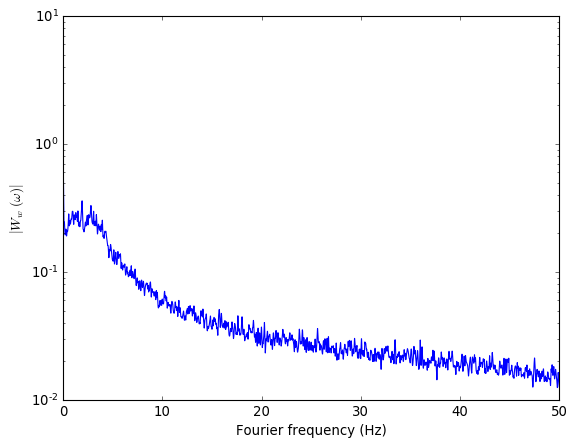

In [13]:
fig,ax = plt.subplots(1)
ax.semilogy(fn,np.abs(Ww))
ax.set_xlabel(r'Fourier frequency (Hz)')
ax.set_ylabel(r'$|W_w~(\omega)|$')

pp = dirpath + '/' + exp_name + '/' + run_name + '/' + 'weinerfilt-Ww.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [337]:
#automatic calibration 
K=1j
Ww = K*np.conj(W1)*np.conj(W2)/Nw

sig_fft = fft.fft(u)
sig_filt = np.real(fft.ifft(sig_fft*Ww))

#determining phase difference from signal correlation
xcorr = signal.correlate(sig_filt,u)
tncorr=dt*np.linspace(-M,M,2*M-1)
tdiff = tncorr[xcorr.argmax()]

#signal amplitude
filt_amp = np.min(sig_filt)
sig_amp = np.min(u)


while filt_amp > sig_amp:
    K += 1j
    Ww = K*np.conj(W1)*np.conj(W2)/Nw

    sig_fft = fft.fft(u)
    sig_filt = np.real(fft.ifft(sig_fft*Ww))
    filt_amp = np.min(sig_filt)
    sig_amp = np.min(u)
    
    

Text(0, 0.5, 'Signal ($\\mu V$)')

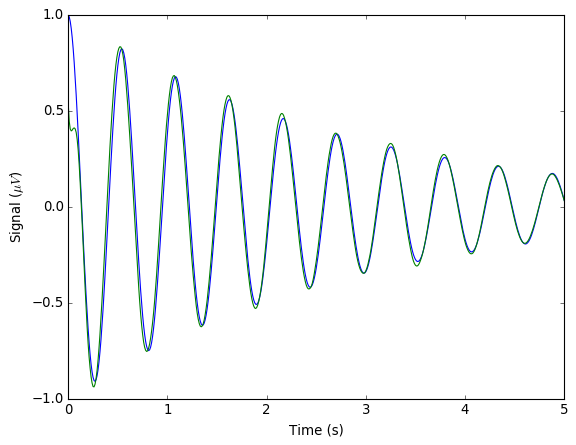

In [338]:
#calibrate the filter by filtering signal (no noise) of known amplitude -> filtered signal should be of same aplitude

sig_fft = fft.fft(u)
sig_filt = np.real(fft.ifft(sig_fft*Ww))


fig,ax = plt.subplots(1)
ax.plot(tn,u)
ax.plot(tn,sig_filt)
ax.set_xlim(0,5)
ax.set_xlabel(r'Time (s)')
ax.set_ylabel(r'Signal ($\mu V$)')

In [339]:
data_fft = fft.fft(part_data[7])
data_filt = np.real(fft.ifft(data_fft*Ww))

(820, 830)

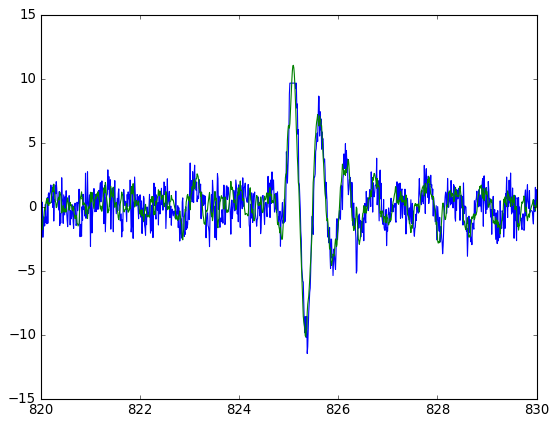

In [340]:
fig, ax = plt.subplots(1)
ax.plot(tn,part_data[7])
ax.plot(tn,data_filt)
ax
ax.set_xlim(820,830)

In [341]:
SNR_wk = np.max(data_filt)/np.std(data_filt)
SNR = np.max(part_data[7])/np.std(part_data[7])

In [342]:
SNR_wk/SNR

1.6855412495180566

Now repeat filtering process on Y channel and calculate mode temperature / depositied energies

In [343]:
data_2 = f['2Y/Data'][nn_2-1000000:1000000+nn_2]
data_2-=np.mean(data_2)

In [344]:
#partitioning data
part_data2 = gw.partition(data_2, 0, M)

In [345]:
fn, Nw = signal.welch(part_data[7], fs = 1/dt, nperseg = M//64, nfft=2*M-1, scaling='spectrum', return_onesided= True)

Ww = K*np.conj(W1)*np.conj(W2)/Nw

data_fft = fft.fft(part_data2[7])
data_filt2 = np.real(fft.ifft(data_fft*Ww))

(820, 830)

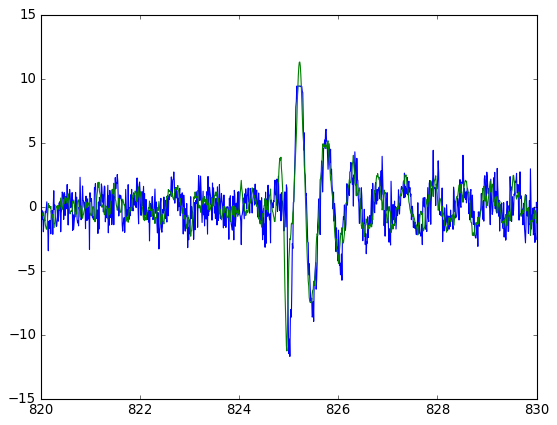

In [346]:
fig, ax = plt.subplots(1)
ax.plot(tn,part_data2[7])
ax.plot(tn,data_filt2)

ax
ax.set_xlim(820,830)

In [308]:
data_filt.shape

(131072,)

In [309]:
r = part_data[7]**2 + part_data2[7]**2
r_wk = data_filt**2 + data_filt2**2

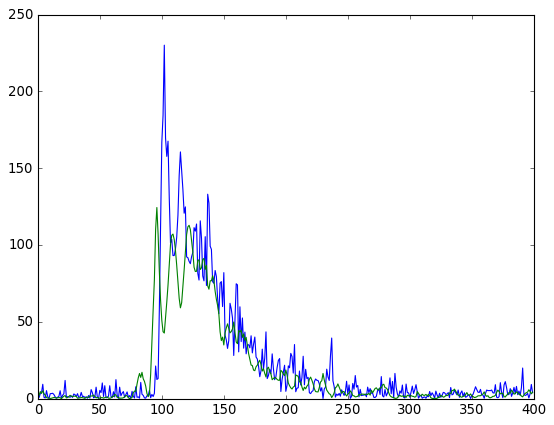

In [310]:
plt.plot(r[82400:82800])
plt.plot(r_wk[82400:82800])

In [272]:
len(r)//500

262

In [273]:
len(Tn)

131072

In [274]:
VtoT = (1.0e-6/Zsquid_3B)**2*R_3B*tau0_3B/kb

In [275]:
Tn = r*VtoT
Tn_wk = r_wk*VtoT

Tn_wk_event = Tn_wk[82549-100:82549+100]

In [276]:
Nbins = 500

Tn_height, Tn_edge = np.histogram(Tn, bins = Nbins)
Tn_wk_height, Tn_wk_edge = np.histogram(Tn_wk, bins = Nbins)


Tfit_m, Tfit_b = np.polyfit(Tn_edge[:30],np.log(Tn_height[:30]),1)
Tfit_wk_m, Tfit_wk_b = np.polyfit(Tn_wk_edge[:30],np.log(Tn_wk_height[:30]),1)

tn_T = np.linspace(0.0,max(Tn_edge)*0.99,Nbins)

In [277]:
excess_events = [excess_index for excess_index in range(len(Tn_wk_height)) if Tn_wk_height[excess_index] > 2*np.exp(Tfit_wk_m*Tn_wk_edge[excess_index]+Tfit_wk_b)]

In [278]:
excess_heights = [Tn_wk_height[i] for i in excess_events]
excess_edges = [Tn_wk_edge[i] for i in excess_events]

In [279]:
len(excess_heights)/Nbins

0.232

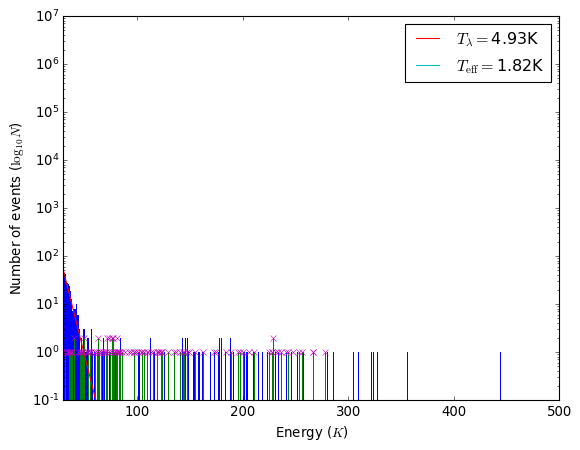

In [280]:
fig,ax = plt.subplots(1)
ax.hist(Tn,bins=Nbins, linewidth=0)
ax.hist(Tn_wk,bins=Nbins,linewidth=0)

ax.plot(tn_T,np.exp(Tfit_m*tn_T+Tfit_b), label = r'$T_\lambda=$%1.2f' % (-1/Tfit_m) + 'K')
ax.plot(tn_T,np.exp(Tfit_wk_m*tn_T+Tfit_wk_b), label = r'$T_\mathrm{eff}=$%1.2f' % (-1/Tfit_wk_m) + 'K')
ax.plot(excess_edges, excess_heights, linestyle = ' ', marker = 'x')
ax.legend(loc=0)
ax.set_yscale('log')
ax.set_ylim(1.0e-1,1.0e+7)
ax.set_xlim(30,500)

ax.set_xlabel(r'Energy ($K$)')
ax.set_ylabel(r'Number of events ($\mathrm{log}_{10}N$)')
pp = dirpath + '/' + exp_name + '/' + run_name + '/' + 'weinerfilt-energyhist.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [281]:
event_N = int(tau0_3B//dt) #exact number of samples for a event corresponding to crystal decay const.

In [282]:
Nbins = M//event_N/2

In [283]:
Nbins

541.5

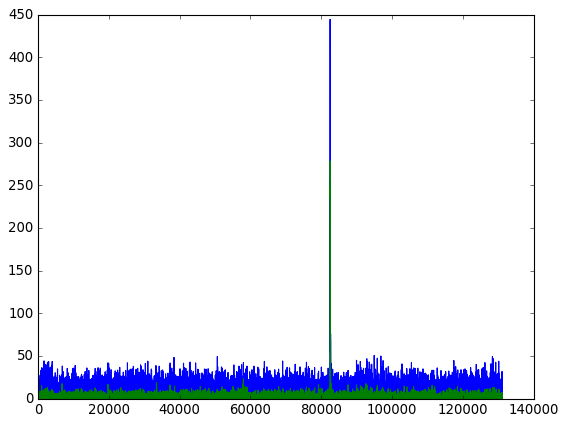

In [331]:
plt.plot(Tn)
plt.plot(Tn_wk)

In [286]:
sigma = np.std(Tn_wk)

In [287]:
mean = np.mean(Tn_wk)

In [291]:
np.max(Tn_wk)/np.std(Tn_wk), np.max(Tn)/np.std(Tn)

(65.83110128849974, 66.36659562076865)

Filtering X and Y channels may be adding some phase noise offset, which causes SNR reduction after recombining X,Y quadratures

In [319]:
events, elapsed = gw.outlier_search(Tn_wk,5)

In [320]:
len(events)

128

In [321]:
5*sigma+mean

23.035840136308664

In [323]:
sigma

4.231961138976983

In [347]:
10*np.log10(3.8)

5.797835966168101